In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import json
from skyfield.api import EarthSatellite, load, wgs84
from datetime import datetime, timezone, timedelta

Re     = 6371.0      
Re_tle = 6378.137     
mu     = 398600.4418  

VN_LAT_MIN, VN_LAT_MAX = 8.0,  23.5
VN_LON_MIN, VN_LON_MAX = 102.0, 110.0

## Tính singele coverage
Một vệ tinh ở độ cao h và half beam angle $\alpha$ có khả năng bao phủ một phần hình cầu trên bề mặt Trái Đất , nửa góc hình nón tính theo tâm Trái Đất của vùng phủ sóng được gọi là góc phủ sóng $\theta$

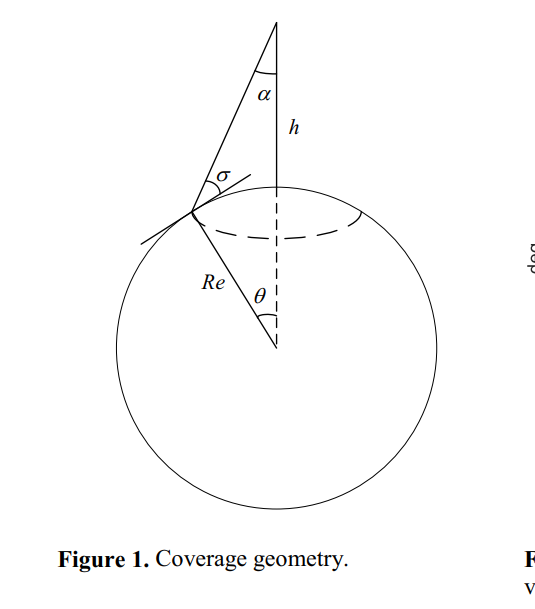

$$ \mathbf{\theta = \arcsin\left(\frac{h + Re}{Re}\sin\alpha\right) - \alpha} \tag {1}$$

In [ ]:
def coverage_angle(h, alpha_deg):
    a   = np.radians(alpha_deg)
    arg = min((h + Re) / Re * np.sin(a), 1.0)
    return np.degrees(np.arcsin(arg) - a)

## SoC Method

### Quan hệ của street width $\psi$ số vệ tinh trên mỗi mặt phẳng $n_2$ và góc phủ $\theta$

**Eq.(4) — Quan hệ θ, ψ, n₂:**
$$\cos\theta = \cos\psi \cdot \cos\!\left(\frac{\pi}{n_2}\right)$$

**Eq.(10) — n₂ tối thiểu:**
$$n_2 \ge \frac{\pi}{\arccos(\cos\theta / \cos\psi_{\min})}$$

**Eq.(11) — Tổng vệ tinh:** $N = n_1 \cdot n_2$ với n1 là số lượng mặt phẳng


In [ ]:
def n2_required(theta_deg, psi_min_deg):
    ct = np.cos(np.radians(theta_deg))
    cp = np.cos(np.radians(psi_min_deg))

    if cp <= 0 or ct / cp >= 1.0:
        return 999
    return int(np.ceil(np.pi/np.arccos(ct/cp)))

## Symmetrical polar

**Eq.(12):** $\psi_{\min} = \dfrac{\pi}{2n_1}$

In [ ]:
def soc_polar_sym(h, alpha_deg, n1_range=range(3, 100)):
    theta = coverage_angle(h, alpha_deg)
    best = {"N" : float("inf")}
    for n1 in n1_range:
        psi_deg = np.degrees(np.pi / (2 * n1))

        if theta <= psi_deg:
            continue

        n2 = n2_required(theta, psi_deg) 

        N= n1*n2
        if N < best["N"]:
            best = {"N": N, "n1": n1, "n2": n2, "psi_min": psi_deg, "theta": theta}
    return best



###  Non - symmertrical polar

**Eq.(14)** $\Delta_1 = \theta + \psi$ (co-rotating interface)

**Eq.(15):** $\Delta_2 = 2\psi$ (counter-rotating interface)

**Eq.(16):** $\Delta_3 = (n_1 - 1)\Delta_1 + \Delta_2 = \pi$

**Eq.(17):** Suy ra $\psi_{min} =  \frac{n_1 - 1}{n_1 + 1}\,\theta$ 



In [ ]:
def soc_polar_nonsym(h, alpha_deg, n1_range(3, 100)):
    theta = coverage_angle(h, alpha_deg)
    theta_rad = np.radians(theta)
    best = {"N" : float ("inf")}

    for n1 in n1_range:
        if n1*theta_rad <= np.pi/2:
            continue

        psi_rad = (n1 - 1)/(n1 +1) * theta_rad
        psi_deg = np.degrees(psi_rad)

        if theta <= psi_rad:
            continue

        n2 = n2_required(theta, psi_deg)
        N = n1*n2

        if N < best ["N"]:
            best = {"N": N, "n1": n1, "n2": n2, "psi_min": psi_deg, "theta": theta}

    return best

### Inclited orbit

**Eq (5)**  $\phi_j = \arctan[\tan i\,\cos(j\pi/n_1)]$

**Eq (6)**  $\sin \psi_{min.m} = \sin X_U\,\cos i / \cos \phi_{m-1}$

**Eq (7)** $X_U = \arctan\{\sin(\frac{m\pi}{n_1})\,\sin(\frac{\pi}{n_1})\,\tan i \{1 + \cos(\frac{m\pi}{n_1}) \, \cos(\frac{\pi}{n_1}) \cos [(m-1)\frac{pi}{n_1}] \,\tan^2 i\}\}$

**Eq.(8):** $\psi_{\text{ext}} = \arcsin[\sin\phi_{\max}\cos i - \cos\phi_{\max}\sin i\cos(\pi/n_1)]$ (vùng ngoài mesh)

**Eq.(9):** $\psi_{\min} = \max(\psi_{\min,1},\ldots,\psi_{\text{ext}})$


